# Plotting PDFs

In [10]:
import sys,os,time
import numpy as np
from mpmath import fp
# from numba import jit
import pandas as pd
import copy

import lhapdf

#--matplotlib
import matplotlib
matplotlib.rcParams['text.latex.preamble']=r"\usepackage{amsmath}"
matplotlib.rc('text',usetex=True)
import pylab  as py
from matplotlib.lines import Line2D

# Look at Trey's PDFs

In [11]:
Q2 = [1.6129,10,100,500,1000]
X = 10**np.linspace(-4,np.log10(0.4),100)
X = np.append(X,np.linspace(0.4,1,101)[1:])

In [12]:
treypdf = np.load("trey24_no_sidis_lo.npy", allow_pickle=True).item()

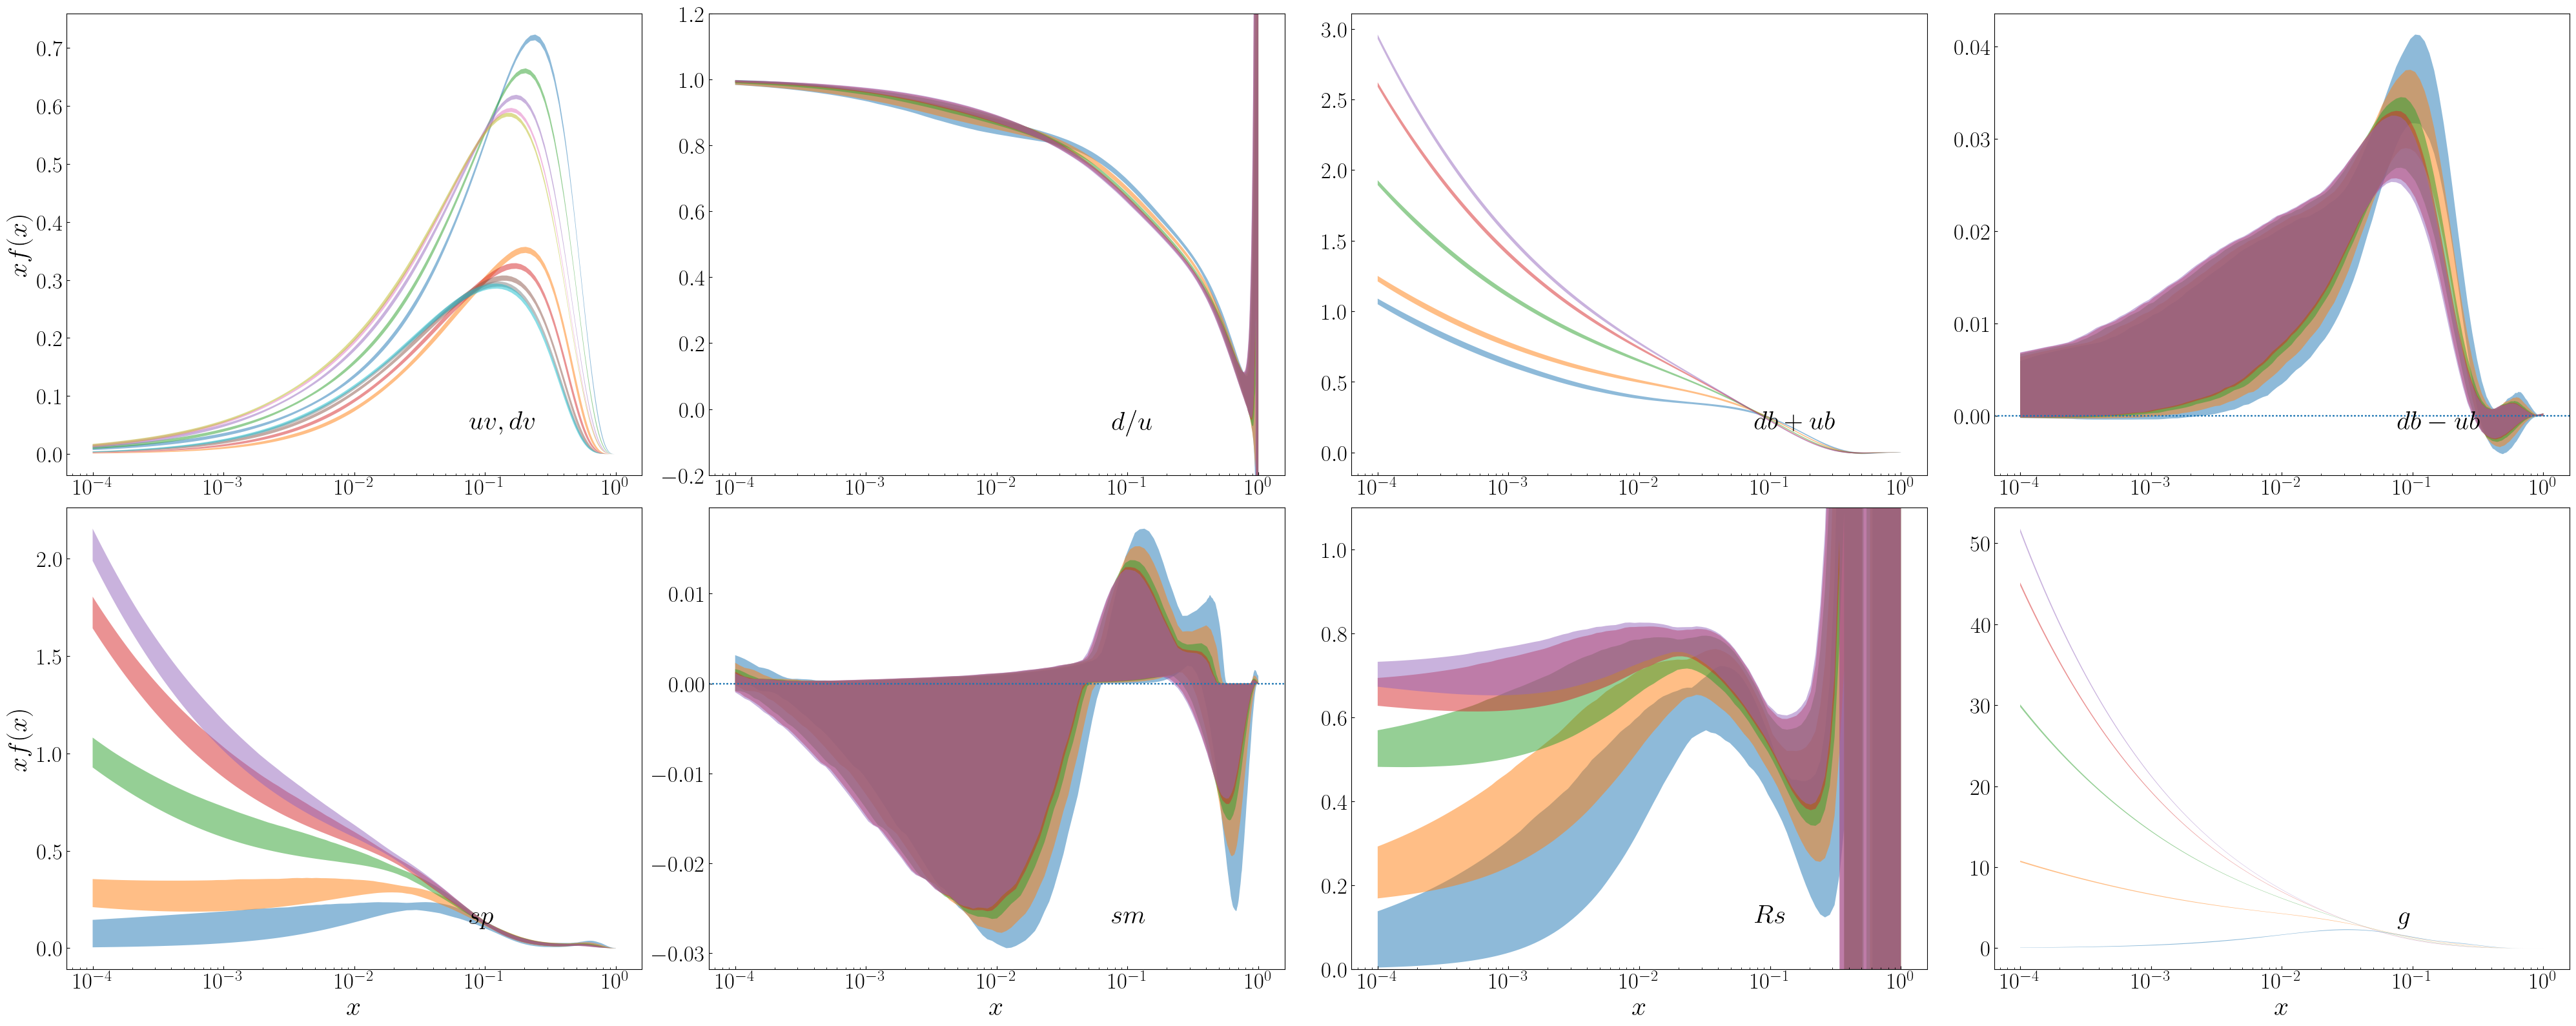

In [13]:
nrows,ncols=2,4
py.figure(figsize=(10*ncols,8*nrows))
cnt=0

plot_flavs=['uv,dv','d/u','db+ub','db-ub','sp','sm','Rs','g']
lower_num = 0.025
upper_num = 0.975

for f in plot_flavs:
    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    for q2 in Q2:

        if f=='uv,dv':
            pdf = treypdf[q2]['uv']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            pdf = treypdf[q2]['dv']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)

            
            # ax.set_ylim(0,0.7)
        elif f=='d/u':
            d = treypdf[q2]['dv'] + treypdf[q2]['db']
            u = treypdf[q2]['uv'] + treypdf[q2]['ub']
            donu = d/u
            lower,upper = np.quantile(donu,lower_num,axis=0),np.quantile(donu,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            ax.set_ylim(-0.2,1.2)
            
        elif f=='db+ub':
            pdf = treypdf[q2]['db'] + treypdf[q2]['ub']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            
        elif f=='db-ub':
            pdf = treypdf[q2]['db'] - treypdf[q2]['ub']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            
            ax.axhline(y=0,ls=':')
        elif f=='sp':
            pdf = treypdf[q2]['s'] + treypdf[q2]['sb']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            
        elif f=='sm':
            pdf = treypdf[q2]['s'] - treypdf[q2]['sb']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            
            ax.axhline(y=0,ls=':')
        elif f=='Rs':
            num = treypdf[q2]['s'] + treypdf[q2]['sb']
            den = treypdf[q2]['ub'] + treypdf[q2]['db']
            pdf = num/den
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            
            ax.set_ylim(0,1.1)
        elif f=='g':
            pdf = treypdf[q2]['g']
            lower,upper = np.quantile(pdf,lower_num,axis=0),np.quantile(pdf,upper_num,axis=0)
            ax.fill_between(X,lower,upper,alpha=0.5)
            
            
    ax.tick_params(direction='in',labelsize=18)
    if cnt>4: ax.set_xlabel(r'$x$',size=30)
    if cnt in [1,5]: ax.set_ylabel(r'$xf(x)$',size=30)
    ax.text(0.7,0.1,r'$%s$'%f,transform=ax.transAxes,size=30)
    #ax.legend(fontsize=16,ncols=3,loc='upper left')
    ax.semilogx()
    # ax.set_xlim(0.01,0.4)
    ax.tick_params(direction='in',labelsize=25,axis='both',which='both')
    # ax.set_ylim(0,2)
    #ax.axhline(y=1)
py.tight_layout()        